# MNIST Classification
**Project 2 — Hands-On ML**

Covers:
- Binary classification (digit 5 detector)
- Performance metrics: confusion matrix, precision, recall, F1, PR curve, ROC/AUC
- Multiclass classification (OvO, Random Forest)
- Multilabel classification

Dataset: MNIST 784 — 70,000 handwritten digit images (28×28 px).

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multiclass import OneVsOneClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score, f1_score,
    precision_recall_curve, roc_curve, roc_auc_score
)
import warnings
warnings.filterwarnings('ignore')

## 1. Load MNIST

In [3]:
mnist = fetch_openml('mnist_784', as_frame=False)
X, y = mnist.data, mnist.target
print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (70000, 784)
y shape: (70000,)


## 2. Visualize Samples

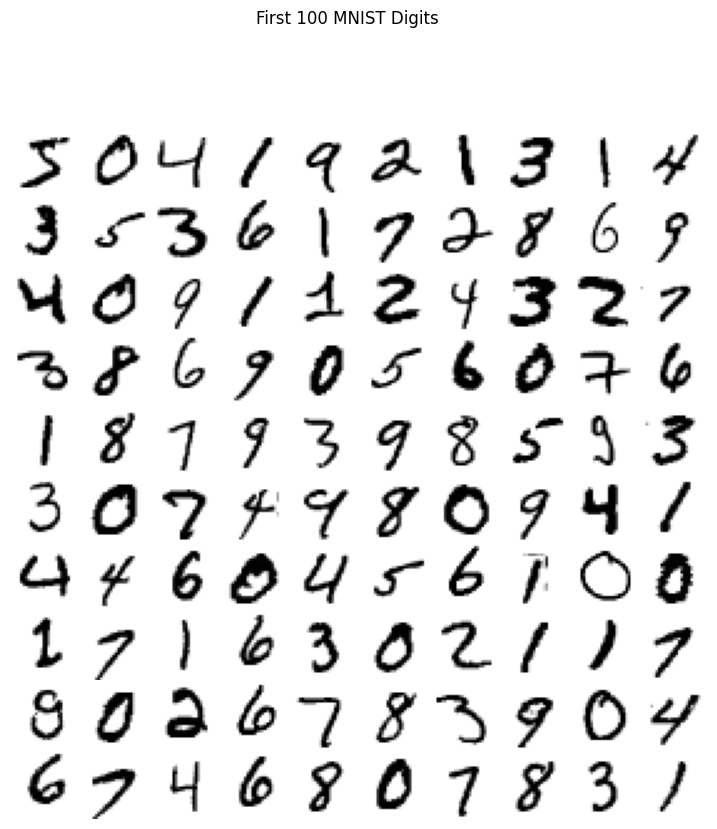

In [4]:
def plot_digit(image_data):
    plt.imshow(image_data.reshape(28, 28), cmap='binary')
    plt.axis('off')

plt.figure(figsize=(9, 9))
for idx in range(100):
    plt.subplot(10, 10, idx + 1)
    plot_digit(X[idx])
plt.subplots_adjust(wspace=0, hspace=0)
plt.suptitle('First 100 MNIST Digits', y=1.01)
plt.show()

## 3. Train-Test Split

MNIST is pre-ordered — first 60K for training, last 10K for test. Shuffle training set to break class ordering.

In [5]:
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

shuf = np.random.permutation(60000)
X_train, y_train = X_train[shuf], y_train[shuf]

## 4. Binary Classification — Digit 5 Detector

In [6]:
y_train_5 = (y_train == '5')
y_test_5 = (y_test == '5')

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

print('Prediction for X[0] (label:', y[0], '):', sgd_clf.predict([X[0]]))

Prediction for X[0] (label: 5 ): [ True]


## 5. Evaluation

### a. Cross-Validation Accuracy

In [7]:
cv_scores = cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring='accuracy')
print('CV Accuracy:', cv_scores)
print('Note: high accuracy is misleading for imbalanced classes (only ~10% are 5s)')

dummy = DummyClassifier()
dummy.fit(X_train, y_train_5)
print('Dummy CV Accuracy:', cross_val_score(dummy, X_train, y_train_5, cv=3, scoring='accuracy'))

CV Accuracy: [0.96305 0.9669  0.95795]
Note: high accuracy is misleading for imbalanced classes (only ~10% are 5s)
Dummy CV Accuracy: [0.90965 0.90965 0.90965]


### b. Confusion Matrix

In [8]:
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)
cm = confusion_matrix(y_train_5, y_train_pred)
print('Confusion Matrix:')
print(cm)
print('TN:', cm[0,0], '| FP:', cm[0,1], '| FN:', cm[1,0], '| TP:', cm[1,1])

Confusion Matrix:
[[53977   602]
 [ 1640  3781]]
TN: 53977 | FP: 602 | FN: 1640 | TP: 3781


### c. Precision, Recall, F1

In [9]:
print(f'Precision: {precision_score(y_train_5, y_train_pred):.4f}')
print(f'Recall:    {recall_score(y_train_5, y_train_pred):.4f}')
print(f'F1:        {f1_score(y_train_5, y_train_pred):.4f}')

Precision: 0.8627
Recall:    0.6975
F1:        0.7713


### d. Precision-Recall Curve

Choose threshold based on the precision-recall tradeoff required for your use case.

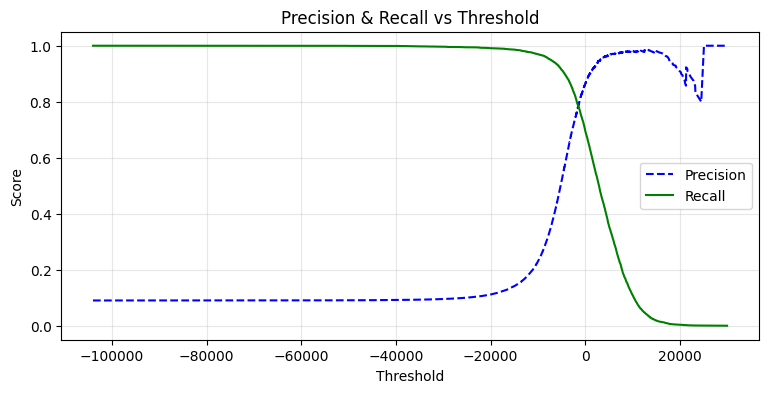

In [10]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3, method='decision_function')
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

plt.figure(figsize=(9, 4))
plt.plot(thresholds, precisions[:-1], 'b--', label='Precision')
plt.plot(thresholds, recalls[:-1], 'g-', label='Recall')
plt.xlabel('Threshold'); plt.ylabel('Score')
plt.title('Precision & Recall vs Threshold')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

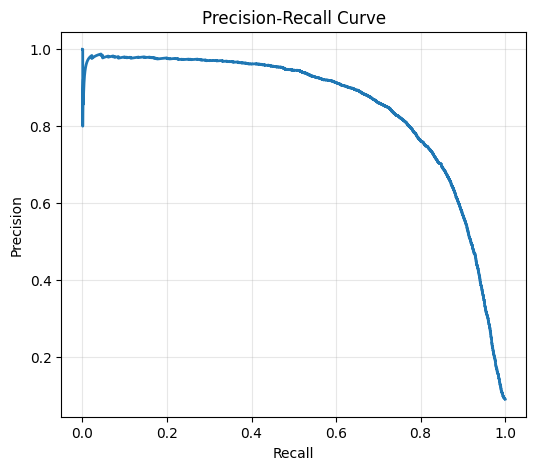

In [11]:
plt.figure(figsize=(6, 5))
plt.plot(recalls, precisions, linewidth=2)
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True, alpha=0.3); plt.show()

### e. ROC Curve & AUC

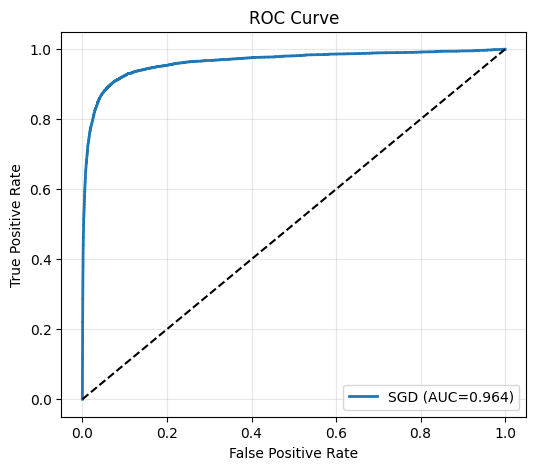

In [12]:
fpr, tpr, _ = roc_curve(y_train_5, y_scores)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, linewidth=2, label=f'SGD (AUC={roc_auc_score(y_train_5, y_scores):.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve'); plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

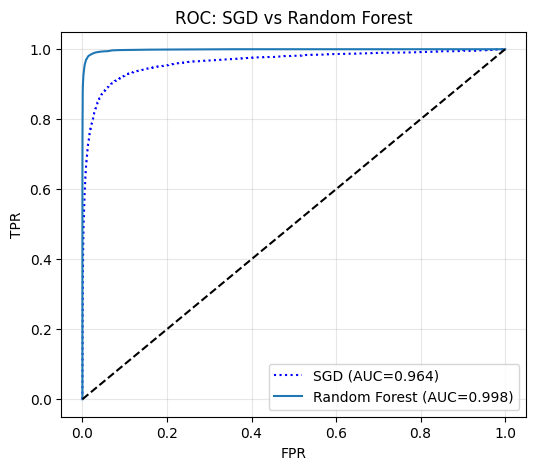

In [13]:
y_proba_forest = cross_val_predict(
    RandomForestClassifier(random_state=42), X_train, y_train_5, cv=3, method='predict_proba'
)
y_scores_forest = y_proba_forest[:, 1]
fpr_f, tpr_f, _ = roc_curve(y_train_5, y_scores_forest)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, 'b:', label=f'SGD (AUC={roc_auc_score(y_train_5, y_scores):.3f})')
plt.plot(fpr_f, tpr_f, label=f'Random Forest (AUC={roc_auc_score(y_train_5, y_scores_forest):.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('ROC: SGD vs Random Forest')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

## 6. Multiclass Classification

SGD is inherently binary. Sklearn auto-applies OvR (one-vs-rest) for multiclass.

In [14]:
sgd_clf.fit(X_train, y_train)
print('Prediction:', sgd_clf.predict([X[0]]), '| True label:', y[0])

Prediction: ['3'] | True label: 5


In [15]:
ovo_clf = OneVsOneClassifier(SGDClassifier(random_state=42))
ovo_clf.fit(X_train, y_train)
print('OvO prediction:', ovo_clf.predict([X[0]]))
print('Number of classifiers:', len(ovo_clf.estimators_))

OvO prediction: ['5']
Number of classifiers: 45


In [16]:
forest_clf = RandomForestClassifier(random_state=42)
forest_clf.fit(X_train, y_train)
print('RF prediction:', forest_clf.predict([X[0]]))
print('Class probabilities:', forest_clf.predict_proba([X[0]]).round(2))

RF prediction: ['5']
Class probabilities: [[0.   0.01 0.02 0.05 0.01 0.89 0.   0.   0.02 0.  ]]


### a. Confusion Matrix — Multiclass

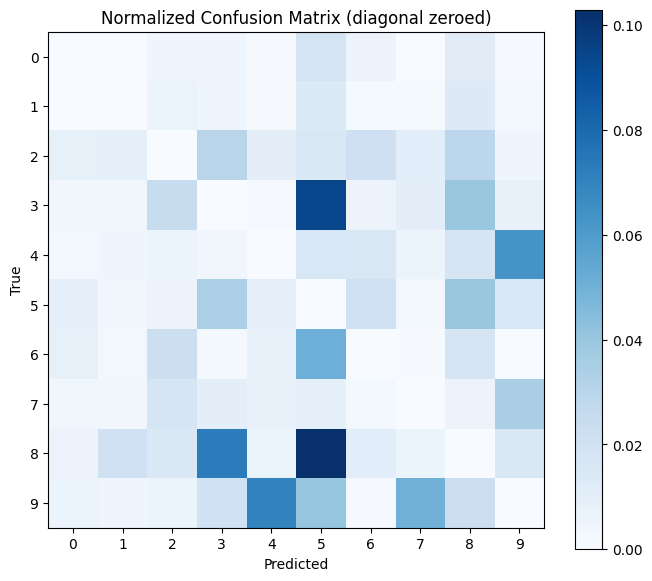

In [17]:
y_train_pred_multi = cross_val_predict(sgd_clf, X_train, y_train, cv=3)
cm_multi = confusion_matrix(y_train, y_train_pred_multi)

# Normalize
cm_norm = cm_multi.astype('float') / cm_multi.sum(axis=1)[:, np.newaxis]
np.fill_diagonal(cm_norm, 0)   # zero diagonal to highlight errors only

plt.figure(figsize=(8, 7))
plt.imshow(cm_norm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar()
plt.title('Normalized Confusion Matrix (diagonal zeroed)')
tick_marks = np.arange(10)
plt.xticks(tick_marks, tick_marks)
plt.yticks(tick_marks, tick_marks)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.show()

## 7. Multilabel Classification

Predict multiple binary tags per image: (is_large_digit, is_odd).

In [18]:
y_train_large = (y_train.astype('int8') >= 7)
y_train_odd = (y_train.astype('int8') % 2 == 1)
y_multilabel = np.c_[y_train_large, y_train_odd]

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)

sample = X[0]
pred = knn_clf.predict([sample])
print(f'Digit: {y[0]} | is_large (>=7): {pred[0][0]} | is_odd: {pred[0][1]}')

Digit: 5 | is_large (>=7): False | is_odd: True


In [ ]:
y_train_knn_pred = cross_val_predict(knn_clf, X_train, y_multilabel, cv=3)

f1_large = f1_score(y_multilabel[:, 0], y_train_knn_pred[:, 0])
f1_odd = f1_score(y_multilabel[:, 1], y_train_knn_pred[:, 1])
f1_macro = f1_score(y_multilabel, y_train_knn_pred, average='macro')

print(f'F1 (is_large >=7): {f1_large:.4f}')
print(f'F1 (is_odd):       {f1_odd:.4f}')
print(f'Macro F1:           {f1_macro:.4f}')

F1 (is_large >=7): 0.9725
F1 (is_odd):       0.9828
Macro F1:           0.9777
